# Session 3 Practical — Hall-Petch Across a Real Literature Dataset (Copper)
### Day 1 | FDP: Machine Learning for Materials and Metallurgical Engineering

**About this dataset:** This session uses real data compiled by Cordero, Knight & Schuh, *"Six decades of the Hall-Petch effect – a survey of grain-size strengthening studies on pure metals,"* International Materials Reviews, 2016. It aggregates **1,445 grain-size/strength measurements across 20 pure metals**, drawn from dozens of independent published studies spanning six decades – real literature data, not a clean textbook table.

**Today's focus: Copper (Cu)** – an FCC metal, with 198 measurements in this dataset, spanning grain sizes from 320 µm down to just 0.004 µm (4 nanometres – genuinely nanocrystalline).

**What's different from Day 1 morning's Hall-Petch notebook:** that used a clean, 7-point table. Today's dataset is *real* – it mixes several different test methods and comes from many independent research groups. Part of this session is learning how to find and prepare the subset of data you actually need from something much larger and messier.

## Step 0 — A Few Python Basics Before We Start

We moved the Python fundamentals here from the morning lecture, so let's walk through them once, quickly, with real code you can run — then we'll never need to stop for syntax again.

This is everything you need to read today's notebook. Nothing more.

### 0a — Variables: storing a value

A variable is just a name that stores a value, created with the `=` sign. Python figures out the type on its own — you don't declare it in advance.

In [1]:
d_new = 0.003
print(d_new)

0.003


Writing `d_new` anywhere else in the code now means "use that stored value." Try changing the number above and re-running the cell — nothing else in this notebook is affected by it, it's just a sandbox.

### 0b — Basic data types we'll see

- **Numbers**: `530`, `7` are whole numbers (integers); `0.0018`, `19.00` are decimals (floats)
- **Text**: `"grain_size_mm"` — text in quotes is a *string*, often used as a column name or label

That's genuinely all the data-type vocabulary needed for today.

In [2]:
whole_number = 7
decimal_number = 0.0018
text_label = "grain_size_mm"

print(type(whole_number))
print(type(decimal_number))
print(type(text_label))

<class 'int'>
<class 'float'>
<class 'str'>


### 0c — Arithmetic operators

Python uses the familiar `+  -  *  /`. One less familiar one we'll use constantly today: `**`, meaning "raised to the power of."

`d ** -0.5` means $d^{-1/2}$ — the exact linearization from this morning's Hall-Petch equation, just written in code.

In [3]:
d = 0.003
print(d ** -0.5)   # same transform as sigma_y = sigma_0 + k * d^(-1/2)

18.257418583505537


**Quick Check 0** — What does `d ** -0.5` compute?

(i) `d` multiplied by -0.5

(ii) `d` raised to the power -0.5 (the same as $d^{-1/2}$)

(iii) `d` divided by -0.5

**Answer: (ii)** — `**` is Python's power/exponent operator, not multiplication or division. This single operator is how the entire linearization step gets written in code, and you'll see it again in Step 3 below.

### 0d — Importing libraries, and the library.function() pattern

A library is a collection of ready-made tools someone else already wrote — we just use it. These three imports are always the first thing to run in any notebook today:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# "as np" just gives the library a short nickname, so we write np.something
# instead of numpy.something every time.
print(np.sqrt(4))   # a function from the numpy library, used as library.function(input)

2.0


That pattern — `library.function(inputs)`, or `column.function()` — is used constantly below: `np.polyfit(x, y, 1)` fits a straight line; `plt.scatter(x, y)` draws a scatter plot; `df["col"].max()` finds a column's largest value. Recognizing this shape is most of what's needed to read the code from here on.

With that, we're ready to start the real analysis.

**A quick note before we load data:** a *DataFrame* (that's what `df` will be) is just a table — rows and named columns, like a spreadsheet. `df = pd.read_csv(...)` loads a CSV straight into that table. Once loaded, square brackets with a column name in quotes — `df["column_name"]` — means "give me that column." You'll see this constantly starting in the very next cell.

## Step 1 — Load the full dataset
Everything loads directly from the course GitHub repo – no file upload needed.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/vijindal/fdp-ml/main/notebooks/hallpetch_multimetal_data.csv"
df = pd.read_csv(DATA_URL)

print("Full dataset shape:", df.shape)
df.head()


Full dataset shape: (1445, 6)


,element,grain_size_um,flow_stress_MPa,plastic_strain,test_method,reference
0,Fe,457.0,75.0,LYS,TT,42
1,Fe,467.0,70.0,LYS,TT,42
2,Fe,260.0,84.0,LYS,TT,42
3,Fe,244.0,82.0,LYS,TT,42
4,Fe,170.0,89.0,LYS,TT,42


## Step 2 — Fetching the Data You Need From a Big Dataset

This dataset has 1,445 rows across 20 metals and 5 test methods. In real research, you almost never work with *all* of it at once – you need to know how to reliably pull out just the subset relevant to your question. Below are several common ways to do that in pandas, each useful in different situations.

### 2a — Get an overview first: how many measurements per metal?

In [6]:
df["element"].value_counts()


,count
element,
Fe,199
Cu,198
Al,171
Nb,92
Be,82
Ti,77
Ni,77
Mg,75
Ta,72


### 2b — Basic filtering: select rows where a column matches a value

In [7]:
cu = df[df["element"] == "Cu"].copy()
print("Copper measurements:", cu.shape[0])
cu.head()


Copper measurements: 198


,element,grain_size_um,flow_stress_MPa,plastic_strain,test_method,reference
533,Cu,240.0,29.0,0.002,TT,72
534,Cu,320.0,30.0,0.002,TT,72
535,Cu,50.0,33.0,0.002,TT,72
536,Cu,50.0,34.0,0.002,TT,72
537,Cu,57.0,32.0,0.002,TT,72


### 2c — Filtering on more than one condition at once

Use `&` (and) or `|` (or) between conditions, with each condition wrapped in parentheses.

In [8]:
cu_tension_only = df[(df["element"] == "Cu") & (df["test_method"] == "TT")].copy()
print("Copper, tension test only:", cu_tension_only.shape[0], "rows")
cu_tension_only.head()


Copper, tension test only: 61 rows


,element,grain_size_um,flow_stress_MPa,plastic_strain,test_method,reference
533,Cu,240.0,29.0,0.002,TT,72
534,Cu,320.0,30.0,0.002,TT,72
535,Cu,50.0,33.0,0.002,TT,72
536,Cu,50.0,34.0,0.002,TT,72
537,Cu,57.0,32.0,0.002,TT,72


### 2d — The same filter, written with `.query()`
Some people find this syntax more readable for multiple conditions.

In [9]:
cu_tension_query = df.query("element == 'Cu' and test_method == 'TT'")
print("Same result?", cu_tension_query.shape[0] == cu_tension_only.shape[0])


Same result? True


### 2e — Summary statistics on a subset

In [10]:
cu["grain_size_um"].describe()


,grain_size_um
count,198.000000
mean,18.955480
std,44.049898
min,0.004000
25%,0.018000
50%,0.165500
75%,18.000000
max,320.000000


### 2f — Sorting to find extremes
Which Cu measurement has the smallest grain size in this dataset?

In [11]:
cu.sort_values("grain_size_um").head(3)


,element,grain_size_um,flow_stress_MPa,plastic_strain,test_method,reference
678,Cu,0.004,838.0,-,VH,80
679,Cu,0.004,870.0,-,VH,80
659,Cu,0.005,733.0,-,VH,79


---
## Quick Check 1

Which line of code would give you **only the Copper rows measured using Vickers hardness (VH)**?

**(i)** `df[df["test_method"] == "VH"]`
**(ii)** `df[(df["element"] == "Cu") & (df["test_method"] == "VH")]`
**(iii)** `df[(df["element"] == "Cu") | (df["test_method"] == "VH")]`

*Think about it, then check the answer below.*

**Answer: (ii)** — option (i) gets Vickers-hardness rows for *every* metal, not just Cu. Option (iii) uses `|` (or), which would return Cu rows *and* all VH rows from every other metal too – far too broad. Only (ii), using `&` (and) with both conditions, correctly narrows to Cu-and-VH-only.

## Step 3 — Linearize: compute grain size to the power -1/2
Same transform as this morning – now applied to a much larger, messier real dataset.

In [12]:
cu["d_inv_sqrt"] = cu["grain_size_um"] ** -0.5
cu[["grain_size_um", "d_inv_sqrt", "flow_stress_MPa", "test_method", "reference"]].head()


,grain_size_um,d_inv_sqrt,flow_stress_MPa,test_method,reference
533,240.0,0.064550,29.0,TT,72
534,320.0,0.055902,30.0,TT,72
535,50.0,0.141421,33.0,TT,72
536,50.0,0.141421,34.0,TT,72
537,57.0,0.132453,32.0,TT,72


**A quick note on the plotting commands below:** every plot in this notebook is built from a small handful of matplotlib commands, called in sequence — `plt.scatter(x, y)` plots individual points, `plt.plot(x, y)` draws a connected line (used later for our fitted line), `plt.xlabel(...)` / `plt.ylabel(...)` / `plt.title(...)` label the plot, and `plt.show()` displays it. That's the whole toolkit.

## Step 4 — Visualize: raw vs. linearized, across all references and test methods

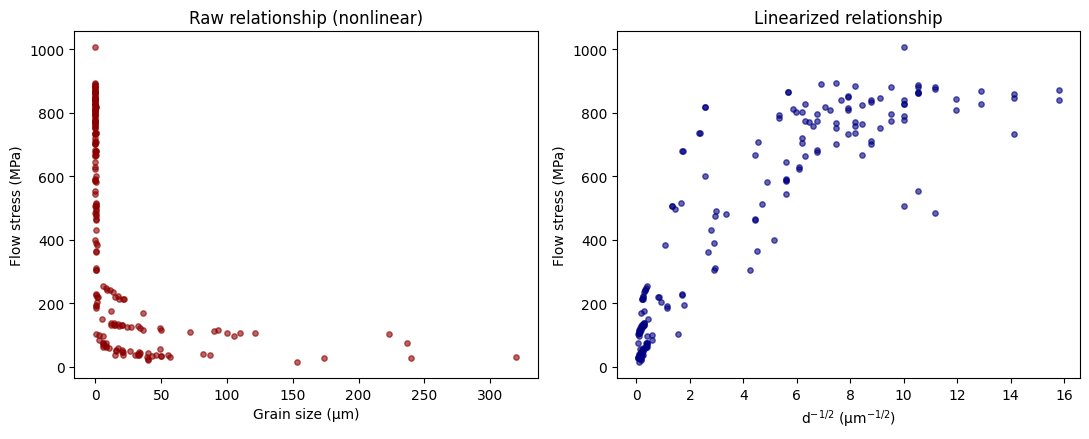

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(cu["grain_size_um"], cu["flow_stress_MPa"], s=15, alpha=0.6, color="darkred")
axes[0].set_xlabel("Grain size (µm)")
axes[0].set_ylabel("Flow stress (MPa)")
axes[0].set_title("Raw relationship (nonlinear)")

axes[1].scatter(cu["d_inv_sqrt"], cu["flow_stress_MPa"], s=15, alpha=0.6, color="navy")
axes[1].set_xlabel("d$^{-1/2}$ (µm$^{-1/2}$)")
axes[1].set_ylabel("Flow stress (MPa)")
axes[1].set_title("Linearized relationship")

plt.tight_layout()
plt.show()


Notice this looks noisier than this morning's 7-point table – that's expected. This is 198 measurements from many independent labs, using different specimens, test methods, and strain rates. Real aggregated literature data always has more scatter than a single controlled experiment.

## Step 4b — What Makes a Fit “Good”? Introducing Loss

We have 198 points and we want to draw the *best* straight line through them – but "best" needs a precise meaning. That's what **loss** gives us: a single number that measures how wrong a candidate line is.

For a candidate line predicting flow stress as $\hat{y} = \sigma_0 + k \cdot x$ (where $x = d^{-1/2}$), the most common choice is **mean squared error (MSE)**:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Squaring each error before averaging does two things: it makes every error positive (so overestimates and underestimates don't cancel out), and it penalizes large errors more heavily than small ones.

In [14]:
def mean_squared_error(sigma0_guess, k_guess, x, y_actual):
    y_pred = sigma0_guess + k_guess * x
    return np.mean((y_actual - y_pred) ** 2)


## Step 4c — Parameters Exploration: Try a Few Guesses by Hand

Before letting an algorithm search for the best (σ0, k), let's try a few guesses ourselves and see which one fits better – exactly what "fitting a model" means underneath.

In [15]:
guesses = {
    "Guess A": (100, 50),
    "Guess B": (150, 70),
    "Guess C": (200, 40),
}

x = cu["d_inv_sqrt"].values
y = cu["flow_stress_MPa"].values

for name, (sigma0_guess, k_guess) in guesses.items():
    loss = mean_squared_error(sigma0_guess, k_guess, x, y)
    print(f"{name}: sigma_0={sigma0_guess}, k={k_guess}  ->  MSE = {loss:,.0f}")


Guess A: sigma_0=100, k=50  ->  MSE = 47,985
Guess B: sigma_0=150, k=70  ->  MSE = 24,392
Guess C: sigma_0=200, k=40  ->  MSE = 43,738


---
## Quick Check 2

Based on the MSE values above, which guess fits the Cu data best – and what does "best" mean here?

**(i)** The guess with the highest MSE – more error means a more powerful model
**(ii)** The guess with the lowest MSE – the smallest average squared error between predictions and actual data
**(iii)** All three guesses are equally good since they're all somewhat close

*Think about it, then check the answer below.*

**Answer: (ii)** — lower MSE means the line's predictions are, on average, closer to the real measurements. "Fitting" a model always means searching for the parameters that make this error as small as possible – whether that search is done by hand (as we just did), by a closed-form formula, or by an iterative algorithm (which we'll build ourselves in Session 4).

## Step 5 — Let an Algorithm Find the Best Parameters

Trying guesses by hand doesn't scale – with 198 points, we want the parameters that minimize MSE *exactly*, not just "pretty good." `np.polyfit` solves exactly this: it searches for the (σ0, k) that gives the lowest possible MSE across all 198 points simultaneously.

In [16]:
k_cu, sigma0_cu = np.polyfit(cu["d_inv_sqrt"], cu["flow_stress_MPa"], 1)

print(f"Copper (Cu) Hall-Petch fit:")
print(f"  sigma_0 = {sigma0_cu:.1f} MPa")
print(f"  k       = {k_cu:.1f} MPa·µm^0.5")


Copper (Cu) Hall-Petch fit:
  sigma_0 = 160.2 MPa
  k       = 68.2 MPa·µm^0.5


---
## Quick Check 3

Copper's fitted σ0 came out to a certain positive value, roughly consistent with copper's known single-crystal strength. What would it mean, physically, if a fit like this produced a **negative** σ0?

**(i)** Nothing unusual – negative values are common and meaningful here
**(ii)** It would suggest something is off – σ0 represents a physical strength floor and shouldn't be negative
**(iii)** It would mean the metal has no grain-boundary strengthening at all

*Think about it, then check the answer below.*

**Answer: (ii)** — σ0 represents the intrinsic lattice resistance to dislocation motion; a real metal's strength floor can't be negative. A negative fitted value would be a signal to check the data (mixed test methods without correction, outliers, or too few high-grain-size points) rather than a real physical result.

## Step 6 — Zooming Into the Nanocrystalline Regime

The dataset includes measurements down to 4 nanometres – far finer than the classical Hall-Petch studies of the 1950s. Does the *same* straight-line fit still describe these ultra-fine-grained points well, or does it break down?

Nanocrystalline points (<1 µm): 114
Conventional/coarse points (>=1 µm): 84


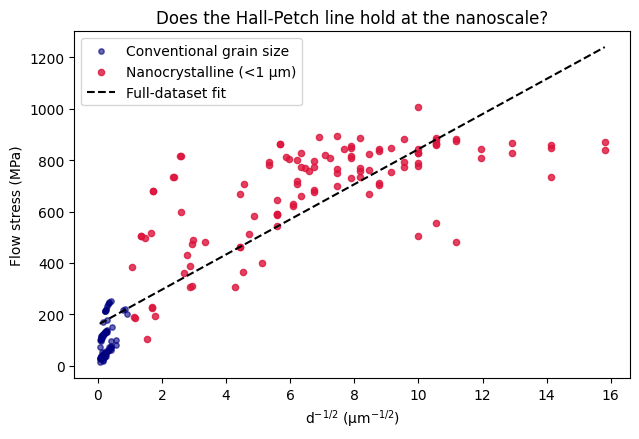

In [17]:
nano = cu[cu["grain_size_um"] < 1.0].copy()
coarse = cu[cu["grain_size_um"] >= 1.0].copy()

print(f"Nanocrystalline points (<1 µm): {len(nano)}")
print(f"Conventional/coarse points (>=1 µm): {len(coarse)}")

plt.figure(figsize=(6.5, 4.5))
plt.scatter(coarse["d_inv_sqrt"], coarse["flow_stress_MPa"], s=15, alpha=0.6, color="navy", label="Conventional grain size")
plt.scatter(nano["d_inv_sqrt"], nano["flow_stress_MPa"], s=20, alpha=0.8, color="crimson", label="Nanocrystalline (<1 µm)")

x_line = np.linspace(cu["d_inv_sqrt"].min(), cu["d_inv_sqrt"].max(), 100)
y_line = sigma0_cu + k_cu * x_line
plt.plot(x_line, y_line, color="black", linestyle="--", label="Full-dataset fit")

plt.xlabel("d$^{-1/2}$ (µm$^{-1/2}$)")
plt.ylabel("Flow stress (MPa)")
plt.title("Does the Hall-Petch line hold at the nanoscale?")
plt.legend()
plt.tight_layout()
plt.show()


---
## Quick Check 4

Looking at the plot above, how well does the single straight-line fit describe the nanocrystalline (red) points compared to the conventional (blue) points?

**(i)** Equally well – no visible difference
**(ii)** The nanocrystalline points scatter noticeably away from the line – the simple model is less reliable at this scale
**(iii)** The nanocrystalline points fit even better than the conventional ones

*This connects directly to what the source paper itself reports – discuss with a neighbor before checking the answer.*

**Answer: (ii)** — this is a real, documented finding: at very fine (nanocrystalline) grain sizes, measured strength increasingly deviates from the simple Hall-Petch line, sometimes falling below the extrapolated trend. This doesn't mean linear regression was done wrong – it means **the underlying physical model itself has a known limited range of validity**. Recognizing when a model's assumptions stop holding is just as important as fitting it correctly in the first place.

---
## (Optional) Stretch — Refit Using Only Tension-Test Data

Earlier we saw Cu's measurements mix several test methods (tension, Vickers hardness, compression, disk-bend). Does restricting to tension tests only – arguably the most directly comparable method – change the fitted σ0 and k noticeably?

In [18]:
cu_tt = cu[cu["test_method"] == "TT"].copy()

k_tt, sigma0_tt = np.polyfit(cu_tt["d_inv_sqrt"], cu_tt["flow_stress_MPa"], 1)

print(f"All test methods:      sigma_0 = {sigma0_cu:.1f} MPa,  k = {k_cu:.1f}")
print(f"Tension tests only:    sigma_0 = {sigma0_tt:.1f} MPa,  k = {k_tt:.1f}")


All test methods:      sigma_0 = 160.2 MPa,  k = 68.2
Tension tests only:    sigma_0 = 46.8 MPa,  k = 130.0


## Wrap-Up

- Copper's Hall-Petch parameters (σ0, k) were fitted from **198 real literature measurements**, not a clean textbook table
- You practiced several ways to **fetch exactly the subset you need** from a large dataset – boolean filtering, multi-condition filtering, `.query()`, `.describe()`, and sorting
- The nanocrystalline points revealed a genuine **limit of the simple Hall-Petch model**

**Next session:** we bring in Iron (BCC) and Titanium (HCP) to compare Hall-Petch behavior across crystal structures – does copper's FCC structure behave differently from a BCC or HCP metal?